In [59]:
import numpy as np
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
kaggle_dir = '/kaggle/input/datasets/organizations/fbi-us/california-crime'
_ca_law_enforcement = 'ca_law_enforcement_by_city.csv'
_ca_offenses = 'ca_offenses_by_city.csv'

df_law = pd.read_csv(os.path.join(kaggle_dir, _ca_law_enforcement))
df_offenses = pd.read_csv(os.path.join(kaggle_dir, _ca_offenses))

df_law.columns = df_law.columns.str.replace('\r', ' ')
df_offenses.columns = df_offenses.columns.str.replace('\r', ' ')

In [21]:
df_law.head()

,City,Population,Total law enforcement employees,Total officers,Total civilians
0,Alameda,"78,613",112,83,29
1,Albany,"19,723",30,23,7
2,Alhambra,"86,175",128,85,43
3,Alturas,"2,566",6,5,1
4,Anaheim,"349,471",577,399,178


In [25]:
df_offenses.head()

,City,Population,Violent crime,Murder and nonnegligent manslaughter,Rape (revised definition),Rape (legacy definition),Robbery,Aggravated assault,Property crime,Burglary,Larceny-theft,Motor vehicle theft,Arson
0,Adelanto,"33,005",212,2,14,NaN,48,148,808,434,254,120,24
1,Agoura Hills,"20,970",15,0,1,NaN,6,8,310,82,217,11,0
2,Alameda,"78,613",148,2,7,NaN,61,78,"1,819",228,"1,245",346,18
3,Albany,"19,723",34,1,6,NaN,16,11,605,95,447,63,0
4,Alhambra3,"86,175",168,1,13,NaN,74,80,"1,929",305,"1,413",211,6


In [26]:
df_merged = pd.merge(
    df_law, 
    df_offenses, 
    on='City', 
    how='inner', 
    suffixes=('_law', '_offense')
)

In [30]:
print(f"Merged dataset shape: {df_merged.shape}")
display(df_merged.head())

Merged dataset shape: (217, 17)


,City,Population_law,Total law enforcement employees,Total officers,Total civilians,Population_offense,Violent crime,Murder and nonnegligent manslaughter,Rape (revised definition),Rape (legacy definition),Robbery,Aggravated assault,Property crime,Burglary,Larceny-theft,Motor vehicle theft,Arson
0,Alameda,"78,613",112,83,29,"78,613",148,2,7,NaN,61,78,"1,819",228,"1,245",346,18
1,Albany,"19,723",30,23,7,"19,723",34,1,6,NaN,16,11,605,95,447,63,0
2,Anderson,"10,277",24,18,6,"10,277",88,0,4,NaN,9,75,474,60,358,56,2
3,Antioch,"110,537",115,91,24,"110,537",771,7,53,NaN,280,431,"3,912",862,"2,026","1,024",36
4,Arcadia,"58,694",93,68,25,"58,694",68,1,6,NaN,31,30,"1,272",316,892,64,3


In [36]:
df_merged.dtypes

City                                     object
Population_law                           object
Total law enforcement employees          object
Total  officers                          object
Total  civilians                         object
Population_offense                       object
Violent crime                            object
Murder and nonnegligent manslaughter      int64
Rape (revised definition)                object
Rape (legacy definition)                float64
Robbery                                  object
Aggravated assault                       object
Property crime                           object
Burglary                                 object
Larceny-theft                            object
Motor vehicle theft                      object
Arson                                    object
dtype: object

In [42]:
columns_to_drop = ['City', 'Population_law', 'Rape (legacy definition)', 'Murder and nonnegligent manslaughter', 'Rape (revised definition)', 'Robbery', 'Aggravated assault', 'Property crime', 'Burglary', 'Larceny-theft', 'Motor vehicle theft', 'Arson']
df_model = df_merged.drop(columns=columns_to_drop)
df_model.head()

,Total law enforcement employees,Total officers,Total civilians,Population_offense,Violent crime
0,112,83,29,"78,613",148
1,30,23,7,"19,723",34
2,24,18,6,"10,277",88
3,115,91,24,"110,537",771
4,93,68,25,"58,694",68


In [54]:
df_model.shape

(217, 5)

In [43]:
df_model.columns

Index(['Total law enforcement employees', 'Total  officers',
       'Total  civilians', 'Population_offense', 'Violent crime'],
      dtype='object')

In [50]:
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = df_model[col].str.replace(',', '')
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

In [44]:
print(df_model.isnull().sum())

Total law enforcement employees    0
Total  officers                    0
Total  civilians                   0
Population_offense                 0
Violent crime                      0
dtype: int64


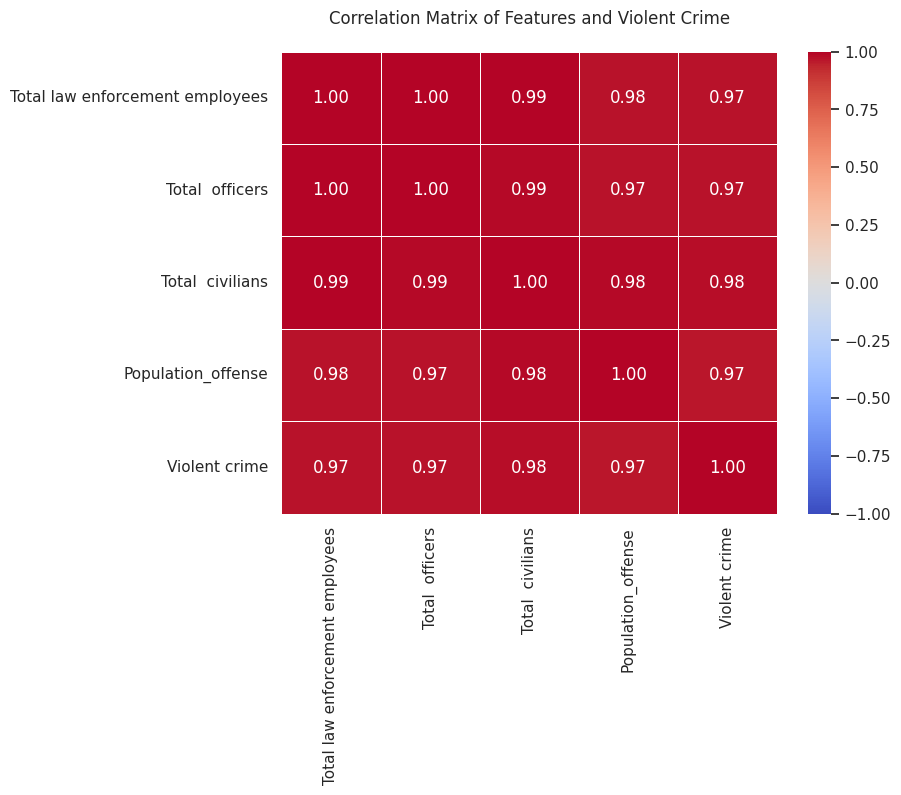

In [51]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
correlation_matrix = df_model.corr()

sns.heatmap(
    correlation_matrix, 
    annot=True,
    cmap='coolwarm',     
    fmt=".2f",     
    linewidths=0.5, 
    vmin=-1, 
    vmax=1     
)
plt.title("Correlation Matrix of Features and Violent Crime", pad=20)
plt.show()

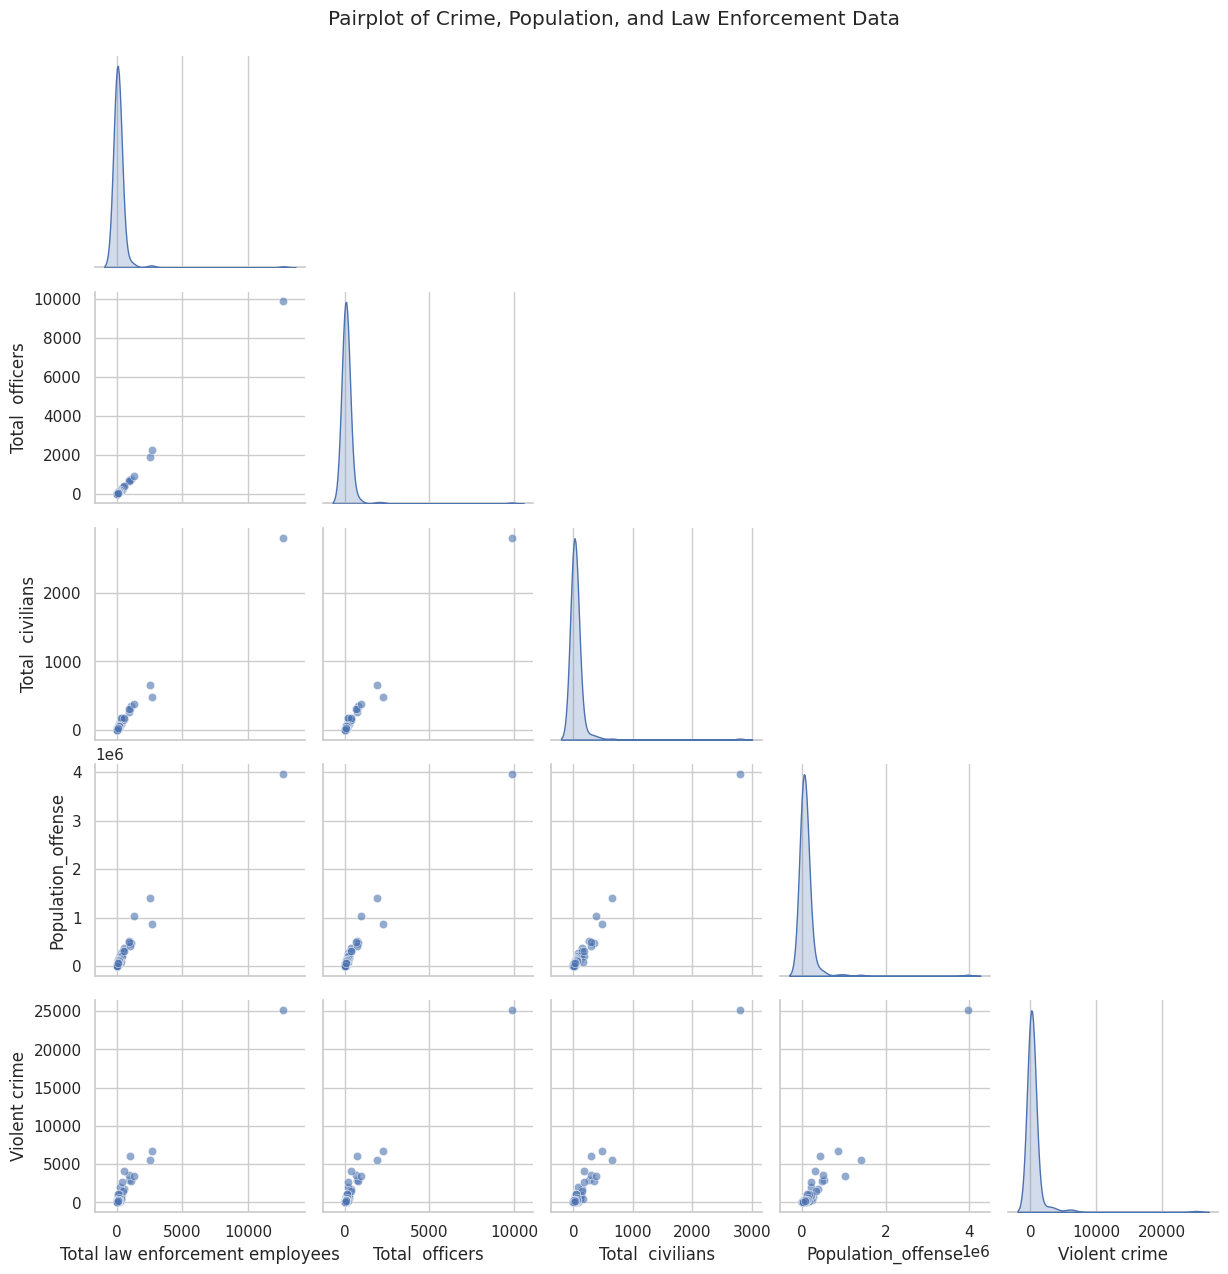

In [53]:
sns.pairplot(df_model, diag_kind='kde', corner=True, plot_kws={'alpha':0.6})
plt.suptitle("Pairplot of Crime, Population, and Law Enforcement Data", y=1.02)
plt.show()

In [57]:
target_col = 'Violent crime'

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

In [69]:
results = []
for name, model in models.items():    
    model.fit(X_train_scaled, y_train)
        
    y_pred = model.predict(X_test_scaled)
        
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
        
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae, 
        "RMSE": mse ** 0.5,
        "Coef_Total_Emp": model.coef_[0],
        "Coef_Officers": model.coef_[1],
        "Coef_Civilians": model.coef_[2],
        "Coef_Population": model.coef_[3]
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,R2 Score,MAE,RMSE,Coef_Total_Emp,Coef_Officers,Coef_Civilians,Coef_Population
0,Linear Regression,0.579628,206.541095,609.017142,769.496139,1166.111577,-622.266157,870.674728
1,Lasso,0.608521,199.683135,587.714729,0.000000,1539.734762,-115.643234,758.757131
2,ElasticNet,0.625930,212.718699,574.498868,486.993185,489.453975,476.492778,481.882059


In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0], 
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99] 
}

elastic_base = ElasticNet(max_iter=20000)

grid_search = GridSearchCV(
    estimator=elastic_base,
    param_grid=param_grid,
    scoring='r2',      
    cv=5,               
    verbose=1      
)

print("Executing Grid Search (this will train 35 different models 5 times each)...")
grid_search.fit(X_train_scaled, y_train)

print("\n--- Grid Search Results ---")
print(f"Optimal Parameters: {grid_search.best_params_}")

best_elastic_model = grid_search.best_estimator_
y_pred_best = best_elastic_model.predict(X_test_scaled)

best_r2 = r2_score(y_test, y_pred_best)
best_rmse = mean_squared_error(y_test, y_pred_best) ** 0.5
best_mae = mean_absolute_error(y_test, y_pred_best)

print("\n--- Test Set Performance (Optimized Model) ---")
print(f"R2 Score: {best_r2:.6f}")
print(f"RMSE:     {best_rmse:.2f}")
print(f"MAE:      {best_mae:.2f}")

print("\nOptimized Coefficients:")
for feature, coef in zip(X.columns, best_elastic_model.coef_):
    print(f"{feature:>35}: {coef:>10.2f}")

Executing Grid Search (this will train 35 different models 5 times each)...
Fitting 5 folds for each of 35 candidates, totalling 175 fits

--- Grid Search Results ---
Optimal Parameters: {'alpha': 0.1, 'l1_ratio': 0.7}

--- Test Set Performance (Optimized Model) ---
R2 Score: 0.658522
RMSE:     548.90
MAE:      189.05

Optimized Coefficients:
    Total law enforcement employees:     570.57
                    Total  officers:     614.47
                   Total  civilians:     411.38
                 Population_offense:     566.94
